# 1 Import Packages

In [1]:
import cantera as ct
import numpy as np
import matplotlib.pyplot as plt
import pandas as pan

# Create Air Mixture Object
air = ct.Solution('gri30.yaml')

# Create Air Fuel Mixture for Combustion Reaction
fuel1 = ct.Solution('gri30.yaml')

# 2 Stage 1 To Stage 6 Turbine

In [27]:
# Define Inlet Conditions to Compressor
P1 = 100000  # Pa (standard pressure)
T1 = 298  # K (standard temperature)

# Compressor Efficiency
Isen_Eff_Comp = 0.90

# Atomic Properties and Mole Fractions and Stoichiometric Combustion Parameters
CH4_Molecular_Weight=12.011+(4*(1.00784)) # Methane Molecular Weight
#H2_Molecular_Weight=2*(1.00784) # Hydrogen Molecular Weight
O2_Molecular_Weight=(2*(15.999)) # O2 Air Molecular Weight
N2_Molecular_Weight=(2*(14.0067)) # N2 Air Molecular Weight
CH4_fuel_stoic_mole=1.0
#H2_fuel_stoic_mole=1.0
O2_air_stoic_CH4_mole=2.0
#O2_air_stoic_H2_mole=0.5
O2_air_vol_mole_fraction=0.21
N2_air_vol_mole_fraction=0.79

# Calculate Mass of Fuel and Air for Stoichiometric Air-Fuel Ratio. Separate Stoichiometric Reactions CH4 + 2O2 -> CO2 + 2H2O and H2 + 0.5O2 -> H2O
mole_CH4_only_stoic_reaction=1.0
#mole_H2_only_stoic_reaction=1.0
CH4_stoic_mass = mole_CH4_only_stoic_reaction * CH4_Molecular_Weight
#H2_stoic_mass = mole_H2_only_stoic_reaction * H2_Molecular_Weight

O2_in_air_mole_stoic_CH4 = CH4_fuel_stoic_mole * O2_air_stoic_CH4_mole
air_total_mole_per_fuel = O2_in_air_mole_stoic_CH4/O2_air_vol_mole_fraction
mass_air_stoic_CH4 = air_total_mole_per_fuel * (O2_air_vol_mole_fraction * O2_Molecular_Weight + N2_air_vol_mole_fraction * N2_Molecular_Weight)

CH4_air_stoic_ratio =  CH4_stoic_mass/mass_air_stoic_CH4

# For Plots
equi_phi_vals = []
T3_vals = []
T3_Actual_vals = []
Cycle_Eff_vals = []
CH4_Frac_vals = []
Pressure_Ratio_vals = []
CO2_mole_fraction_vals = []
N2_mole_fraction_vals = []
NOx_mole_fraction_vals = []
#SOX_mole_fraction_vals = []
H2O_mole_fraction_vals = []
CO2_mass_fraction_vals = []
N2_mass_fraction_vals = []
NOx_mass_fraction_vals = []
#SOx_mass_fraction_vals = []
H2O_mass_fraction_vals = []
Compressor_Work_vals = []
Cooling_Air_Mass_vals = []
Heat_in_vals = []
Turbine_Work_vals = []
Net_Work_vals = []

# Loop over Compressor Pressure Ratio (10 to 20)
for PR in range (10,21,1):  # Pressure ratio from 10 to 20 in steps of 1

# Combustion in Combustion Chamber
    # Loop over Equivalence Ratio from 0 to 1 in steps of 0.1
    for equi_phi in np.arange (0.1,1.1,0.1):
        
        # Loop over Hydrogen Percentage (0% to 100%)
        for CH4_frac in np.arange (0.1,1.1,0.1):  # Equivalence Ratio from 0% to 100% in steps of 10%

            # Define fuel mole fractions
            fuel_mole_fraction = {'CH4': CH4_frac}
            
            # Set fuel-air mixture
            air_mole_fractions = {'O2': 0.21, 'N2': 0.79}

            # Set Compressor Inlet State
            air.TPX=T1,P1, air_mole_fractions

            H1 = air.enthalpy_mass
            S1 = air.entropy_mass
            
            # Isentropic Compression from P1 to P2
            P2 = P1*PR
            S2 = S1
            air.SP = S2, P2
            T2s = air.T

            # Find Specific Heat Capacity at Constant Pressure for Air for Computing Heat Gain By Cooling Air in Else Loop When T3 is Higher than T3_Max
            Air_Spec_Capacity_Cp = air.cp_mass

            # Isentropic Enthalpy After Compression
            H2s = air.enthalpy_mass

            # Actual Enthalpy After Compression
            H2 = H1 + ((H2s-H1)/Isen_Eff_Comp)

            # Set State of Air With Actual Enthalpy H2
            air.HP = H2, P2
            T2 = air.T
       
            # Find Mass of Fuel Using Mole Fraction From Actual Specified CH4_frac-H2_frac Volume Fraction Loop
            mass_of_CH4 = CH4_frac * CH4_Molecular_Weight

            mass_fuel = mass_of_CH4
  
            # Mass of Air From Compressor for Combustion 
            Comp_Mass_Air = mass_fuel/(equi_phi*CH4_air_stoic_ratio) # Mass of Air Compressed by Compressor for Combustion [kg]

            # If Combustor Exhaust Temperature is Lower Than The Maximum Turbine Inlet Temperature No Turbine Cooling
            mass_cool_air = 0

            # Create New Air Fuel Mixture for Combustion Reaction
            fuel1 = ct.Solution('gri30.yaml')   

            # Set Mixture Temperature and Pressure To Premix Air and Fuel
            fuel1.TP=T2, P2

            # Simulate the Combustion to Calculate Temperature, T3 of The Combustion Gas
            fuel1.set_equivalence_ratio(phi=equi_phi, fuel=fuel_mole_fraction, oxidizer=air_mole_fractions)

            # Find Enthalpy of Air-Fuel Mixture at Compressor Temperature and Pressure
            H2constH2 = fuel1.enthalpy_mass

            # Combust the Air-Fuel Mixture At Constant Enthalpy To Obtain Combustion Gases Temperature T3
            fuel1.equilibrate('HP')

            # Find Mole Fractions of Reaction Products:CO2, H2O, N2, NOx and SOx Formation Before Cooling
            mole_fraction_CO2_Before_Cooling = fuel1['CO2'].X[0]
            mole_fraction_N2_Before_Cooling = fuel1['N2'].X[0]
            mole_fraction_H2O_Before_Cooling = fuel1['H2O'].X[0]
            mole_fraction_NO_Before_Cooling = fuel1['NO'].X[0]
            mole_fraction_NO2_Before_Cooling = fuel1['NO2'].X[0]
            mole_fraction_NOx_Before_Cooling = mole_fraction_NO_Before_Cooling + mole_fraction_NO2_Before_Cooling
            
            # mole_fraction_SO2 = fuel1['SO2'].X[0]
            # mole_fraction_SO3 = fuel1['SO3'].X[0]
            # mole_fraction_SOx = mole_fraction_SO2 + mole_fraction_SO3

            mass_fraction_CO2_Before_Cooling = fuel1['CO2'].Y[0]
            mass_fraction_N2_Before_Cooling = fuel1['N2'].Y[0]
            mass_fraction_H2O_Before_Cooling = fuel1['H2O'].Y[0]
            mass_fraction_NO_Before_Cooling = fuel1['NO'].Y[0]
            mass_fraction_NO2_Before_Cooling = fuel1['NO2'].Y[0]
            mass_fraction_NOx_Before_Cooling = mass_fraction_NO_Before_Cooling + mass_fraction_NO2_Before_Cooling

            # mass_fraction_SO2 = fuel1['SO2'].Y[0]
            # mass_fraction_SO3 = fuel1['SO3'].Y[0]
            # mass_fraction_SOx = mass_fraction_SO2 + mass_fraction_SO3

            # Adiabetic Flame Temperature        
            T3 = fuel1.T

            # Equlibrate at T3, Adiabetic Flame Temperature To Get Heat Added by Combustion
            # Set Mixture Temperature and Pressure of Premix Air and Fuel to Adiabetic flame Temperature, T3 and P2
            fuel1.TP=T3, P2

            # Simulate the Combustion to Calculate Enthalpy, H3 of The Combustion Gas
            fuel1.set_equivalence_ratio(phi=equi_phi, fuel=fuel_mole_fraction, oxidizer=air_mole_fractions)

            # Find Enthalpy and Entropy After Combustion at T3 and P2.
            H3 = fuel1.enthalpy_mass
            S3 = fuel1.entropy_mass

            T3_Max = 2000 # Maximum Turbine Inlet Temperature. Calculate Cooling Air if T3 Exceeds T3_Max
            mass_cool_air = 0 # If Combustor Exhaust Temperature is Higher Than The Maximum Turbine Inlet Temperature

            # Compressor Work, Combustion Energy and Turbine Work If Combustion Gas Temperatures are Below Maximum Turbine Inlet Temperature
            if T3<=T3_Max:
                #Actual T3 Values for Analysis
                T3_Actual=T3
                
                # Calculate Compressor Air for Combustion
                mass_cool_air = 0 # If Combustor Exhaust Temperature is Higher Than The Maximum Turbine Inlet Temperature. Set To Zero Because In This Loop, T3 is Less Than T3_Max

                Comp_Mass_Air_Cooling = Comp_Mass_Air + mass_cool_air # mass_cool_air is Volume of Cooling Air Required if Turbine Inlet is Higher than Maximum Turbine Inlet Temperature. Set To Zero Because In This Loop, T3 is Less Than T3_Max          
                mass_fuel_air_in_combustor_turbine = Comp_Mass_Air + mass_cool_air + mass_fuel # mass_cool_air is Volume of Cooling Air Required if Turbine Inlet is Higher than Maximum Turbine Inlet Temperature. Set To Zero Because In This Loop, T3 is Less Than T3_Max

                # Compressor Work With Air Flow Accounted For. In Compressor, Gas Is Only Air
                W_Comp=Comp_Mass_Air_Cooling*Isen_Eff_Comp*(H2-H1)

                # Compute Heat Added
                Heat_in=mass_fuel_air_in_combustor_turbine*(H3-H2)

                # Turbine Section Isentropic Expansion
                Isen_Eff_Turb = 0.90 # Turbine Efficiency

                # Reset the Combustion Mixture in the Turbine to S3 and P1, Exhaust Pressure               
                S4 = S3
                fuel1.SP = S4, P1
                
                fuel1.set_equivalence_ratio(phi=equi_phi, fuel=fuel_mole_fraction, oxidizer=air_mole_fractions)
                
                # Isentropic Enthalpy After Expansion in Turbine                
                H4s = fuel1.enthalpy_mass

                # Actual Enthalpy After Expansion in Turbine
                H4 = H3 - Isen_Eff_Turb * (H3 - H4s)   

                # Turbine Work
                W_Turb = mass_fuel_air_in_combustor_turbine*Isen_Eff_Turb*(H3-H4)

                # Gas Turbine Efficiency
                Net_Work = W_Turb-W_Comp
                Cycle_Eff = Net_Work/Heat_in

                # Mole Fractions of Reaction Products Same As Above Because No Recombustion To Account for Turbine Cooling 

            # Compressor Work, Combustion Energy and Turbine Work If Combustion Gas Temperatures are Above Maximum Turbine Inlet Temperature
            elif T3>T3_Max:
                # If T3 > T3_Max, Then Cool The Combustion Gases. H2 of Compresssed Air Remains the Same. Stoichiometric Air-Fuel Ratio Also Remains the Same Because Combustion has Already Occured, the Extra Air is Just for Cooling
                # Solve for Cooling Air Mass That Is Heated From T3_Max to T3, Temperature Above T3_Max. This Is Equal To Energy Gained By Cooling Air To Cool The Combustion Gas from Temperature T3, Above T3_Max to T3_Max
                H_Above_T3_Max = H3

                # Set Combusted Mixture To T3_Max and P2 for Calculating Difference in Enthalpy from H_Above_T3_Max and H3_Max
                fuel1.TP=T3_Max, P2
                
                fuel1.set_equivalence_ratio(phi=equi_phi, fuel=fuel_mole_fraction, oxidizer=air_mole_fractions)

                H3_Max = fuel1.enthalpy_mass # Target Enthalpy
                S3_Max = fuel1.entropy_mass

                # Find Mass of Cooling Air From Change in Enthalpy of Cooling Air Which is Cooled at Constant Pressure i.e. H_Cooling=mass_cooling_air*cp(T3-T3_Max)
                H_Cooling_Energy = H_Above_T3_Max - H3_Max
                mass_cooling_air = H_Cooling_Energy/(Air_Spec_Capacity_Cp*(T3-T3_Max))

                # New Compressor Air with Cooling Air
                Comp_Mass_Air_Cooling = Comp_Mass_Air + mass_cooling_air

                mass_fuel_air_cooling_air_in_turbine = mass_fuel + Comp_Mass_Air_Cooling # mass_cooling_air is Volume of Cooling Air Required if Turbine Inlet is Higher than Maximum Turbine Inlet Temperature. Mass of Cooling Air is Calculated in This Loop Because T3 > T3_Max

                # Mass of Fuel and Combustion Air From Compressor for Heat_In Calculation
                mass_fuel_air_in_combustor = Comp_Mass_Air + mass_fuel # mass_cool is Volume of Cooling Air Required if Turbine Inlet is Higher than Maximum Turbine Inlet Temperature. Mass of Cooling Air is Calculated in This Loop Because T3 > T3_Max

                # Not Recombusting. Reduce Enthalpy H3 by H_Cooling_Energy by Setting H3 to H3_Max, Heat_in Accounts for Energy For Cooling by Reducing the Enthalpy of the Combustion gas from H3 to H3_Max, Hence Reduced Work Extraction by the Turbine
                Heat_in = mass_fuel_air_in_combustor*(H3-H2)

                #Actual T3 Values for Analysis
                T3_Actual=T3

                # Set T3 to T3_Max for Plotting T3 Values
                T3=T3_Max

                # Compressor Work With Cooling Air Accounted For. In Compressor, Gas Is Only Air
                W_Comp=Comp_Mass_Air_Cooling*Isen_Eff_Comp*(H2-H1)

                # Turbine Section Isentropic Expansion
                Isen_Eff_Turb = 0.90 # Turbine Efficiency                

                # Set Combusted Mixture To S3_Max at Lower Energy Level of Cooled Combustion Gases Before Entering Turbine and Atmospheric Pressure, P1 for Expansion in Turbine
                S4 = S3_Max

                fuel1.SP = S4, P1

                fuel1.set_equivalence_ratio(phi=equi_phi, fuel=fuel_mole_fraction, oxidizer=air_mole_fractions)
                
                # Isentropic Enthalpy After Expansion in Turbine                
                H4s = fuel1.enthalpy_mass

                # Actual Enthalpy After Expansion in Turbine
                H4 = H3_Max - Isen_Eff_Turb*(H3_Max-H4s)

                # Turbine Work. Reduce Enthalpy H3 by H_Cooling_Energy by Setting H3 to H3_Max, Heat_in Accounts for Energy For Cooling by Reduce the Enthalpy of the Combustion gas from H3 to H3_Max, Hence Reduced Work Extraction by the Turbine
                W_Turb = mass_fuel_air_cooling_air_in_turbine*Isen_Eff_Turb*(H3_Max-H4)                

                # Gas Turbine Efficiency
                Net_Work = W_Turb-W_Comp
                Cycle_Eff = Net_Work/Heat_in

            else:
                print("Error T3 is Not Positive")

            equi_phi_vals.append(equi_phi)
            T3_vals.append(T3)
            T3_Actual_vals.append(T3_Actual)
            Cycle_Eff_vals.append(Cycle_Eff)
            CH4_Frac_vals.append(CH4_frac)
            Pressure_Ratio_vals.append(PR)
            CO2_mole_fraction_vals.append(mole_fraction_CO2_Before_Cooling)
            N2_mole_fraction_vals.append(mole_fraction_N2_Before_Cooling)
            NOx_mole_fraction_vals.append(mole_fraction_NOx_Before_Cooling)
            #SOX_mole_fraction_vals.append(mole_fraction_SOx_Before_Cooling)
            H2O_mole_fraction_vals.append(mole_fraction_H2O_Before_Cooling)
            CO2_mass_fraction_vals.append(mass_fraction_CO2_Before_Cooling)
            N2_mass_fraction_vals.append(mass_fraction_N2_Before_Cooling)
            NOx_mass_fraction_vals.append(mass_fraction_NOx_Before_Cooling)
            #SOx_mass_fraction_vals.append(mass_fraction_SOx_Before_Cooling)       
            H2O_mass_fraction_vals.append(mass_fraction_H2O_Before_Cooling)
            Compressor_Work_vals.append(W_Comp)
            Cooling_Air_Mass_vals.append(Comp_Mass_Air_Cooling)
            Heat_in_vals.append(Heat_in)
            Turbine_Work_vals.append(W_Turb)
            Net_Work_vals.append(Net_Work)

In [ ]:
# Define Inlet Conditions to Compressor
P1 = 100000  # Pa (standard pressure)
T1 = 298  # K (standard temperature)

# Compressor Efficiency
Isen_Eff_Comp = 0.90

# Atomic Properties and Mole Fractions and Stoichiometric Combustion Parameters
CH4_Molecular_Weight=12.011+(4*(1.00784)) # Methane Molecular Weight
#H2_Molecular_Weight=2*(1.00784) # Hydrogen Molecular Weight
O2_Molecular_Weight=(2*(15.999)) # O2 Air Molecular Weight
N2_Molecular_Weight=(2*(14.0067)) # N2 Air Molecular Weight
CH4_fuel_stoic_mole=1.0
#H2_fuel_stoic_mole=1.0
O2_air_stoic_CH4_mole=2.0
#O2_air_stoic_H2_mole=0.5
O2_air_vol_mole_fraction=0.21
N2_air_vol_mole_fraction=0.79

# Calculate Mass of Fuel and Air for Stoichiometric Air-Fuel Ratio. Separate Stoichiometric Reactions CH4 + 2O2 -> CO2 + 2H2O and H2 + 0.5O2 -> H2O
mole_CH4_only_stoic_reaction=1.0
#mole_H2_only_stoic_reaction=1.0
CH4_stoic_mass = mole_CH4_only_stoic_reaction * CH4_Molecular_Weight
#H2_stoic_mass = mole_H2_only_stoic_reaction * H2_Molecular_Weight

O2_in_air_mole_stoic_CH4 = CH4_fuel_stoic_mole * O2_air_stoic_CH4_mole
air_total_mole_per_fuel = O2_in_air_mole_stoic_CH4/O2_air_vol_mole_fraction
mass_air_stoic_CH4 = air_total_mole_per_fuel * (O2_air_vol_mole_fraction * O2_Molecular_Weight + N2_air_vol_mole_fraction * N2_Molecular_Weight)

CH4_air_stoic_ratio =  CH4_stoic_mass/mass_air_stoic_CH4

# For Plots
equi_phi_vals = []
T3_vals = []
T3_Actual_vals = []
Cycle_Eff_vals = []
CH4_Frac_vals = []
Pressure_Ratio_vals = []
CO2_mole_fraction_vals = []
N2_mole_fraction_vals = []
NOx_mole_fraction_vals = []
#SOX_mole_fraction_vals = []
H2O_mole_fraction_vals = []
CO2_mass_fraction_vals = []
N2_mass_fraction_vals = []
NOx_mass_fraction_vals = []
#SOx_mass_fraction_vals = []
H2O_mass_fraction_vals = []
Compressor_Work_vals = []
Cooling_Air_Mass_vals = []
Heat_in_vals = []
Turbine_Work_vals = []
Net_Work_vals = []

results = {}
# Loop over Compressor Pressure Ratio (10 to 20)
for PR in range (10,21,1):  # Pressure ratio from 10 to 20 in steps of 1

# Combustion in Combustion Chamber
    # Loop over Equivalence Ratio from 0 to 1 in steps of 0.1
    for equi_phi in np.arange (0.1,1.1,0.1):
        
        # Loop over Hydrogen Percentage (0% to 100%)
        for CH4_frac in np.arange (0.1,1.1,0.1):  # Equivalence Ratio from 0% to 100% in steps of 10%

            # Define fuel mole fractions
            fuel_mole_fraction = {'CH4': CH4_frac}
            
            # Set fuel-air mixture
            air_mole_fractions = {'O2': 0.21, 'N2': 0.79}

            # Set Compressor Inlet State
            air.TPX=T1,P1, air_mole_fractions

            H1 = air.enthalpy_mass
            S1 = air.entropy_mass
            
            # Isentropic Compression from P1 to P2
            P2 = P1*PR
            S2 = S1
            air.SP = S2, P2
            T2s = air.T

            # Find Specific Heat Capacity at Constant Pressure for Air for Computing Heat Gain By Cooling Air in Else Loop When T3 is Higher than T3_Max
            Air_Spec_Capacity_Cp = air.cp_mass

            # Isentropic Enthalpy After Compression
            H2s = air.enthalpy_mass

            # Actual Enthalpy After Compression
            H2 = H1 + ((H2s-H1)/Isen_Eff_Comp)

            # Set State of Air With Actual Enthalpy H2
            air.HP = H2, P2
            T2 = air.T
       
            # Find Mass of Fuel Using Mole Fraction From Actual Specified CH4_frac-H2_frac Volume Fraction Loop
            mass_of_CH4 = CH4_frac * CH4_Molecular_Weight

            mass_fuel = mass_of_CH4
  
            # Mass of Air From Compressor for Combustion 
            Comp_Mass_Air = mass_fuel/(equi_phi*CH4_air_stoic_ratio) # Mass of Air Compressed by Compressor for Combustion [kg]

            # If Combustor Exhaust Temperature is Lower Than The Maximum Turbine Inlet Temperature No Turbine Cooling
            mass_cool_air = 0

            # Create New Air Fuel Mixture for Combustion Reaction
            fuel1 = ct.Solution('gri30.yaml')   

            # Set Mixture Temperature and Pressure To Premix Air and Fuel
            fuel1.TP=T2, P2

            # Simulate the Combustion to Calculate Temperature, T3 of The Combustion Gas
            fuel1.set_equivalence_ratio(phi=equi_phi, fuel=fuel_mole_fraction, oxidizer=air_mole_fractions)

            # Find Enthalpy of Air-Fuel Mixture at Compressor Temperature and Pressure
            H2constH2 = fuel1.enthalpy_mass

            # Combust the Air-Fuel Mixture At Constant Enthalpy To Obtain Combustion Gases Temperature T3
            fuel1.equilibrate('HP')

            # Find Mole Fractions of Reaction Products:CO2, H2O, N2, NOx and SOx Formation Before Cooling
            mole_fraction_CO2_Before_Cooling = fuel1['CO2'].X[0]
            mole_fraction_N2_Before_Cooling = fuel1['N2'].X[0]
            mole_fraction_H2O_Before_Cooling = fuel1['H2O'].X[0]
            mole_fraction_NO_Before_Cooling = fuel1['NO'].X[0]
            mole_fraction_NO2_Before_Cooling = fuel1['NO2'].X[0]
            mole_fraction_NOx_Before_Cooling = mole_fraction_NO_Before_Cooling + mole_fraction_NO2_Before_Cooling
            
            # mole_fraction_SO2 = fuel1['SO2'].X[0]
            # mole_fraction_SO3 = fuel1['SO3'].X[0]
            # mole_fraction_SOx = mole_fraction_SO2 + mole_fraction_SO3

            mass_fraction_CO2_Before_Cooling = fuel1['CO2'].Y[0]
            mass_fraction_N2_Before_Cooling = fuel1['N2'].Y[0]
            mass_fraction_H2O_Before_Cooling = fuel1['H2O'].Y[0]
            mass_fraction_NO_Before_Cooling = fuel1['NO'].Y[0]
            mass_fraction_NO2_Before_Cooling = fuel1['NO2'].Y[0]
            mass_fraction_NOx_Before_Cooling = mass_fraction_NO_Before_Cooling + mass_fraction_NO2_Before_Cooling

            # mass_fraction_SO2 = fuel1['SO2'].Y[0]
            # mass_fraction_SO3 = fuel1['SO3'].Y[0]
            # mass_fraction_SOx = mass_fraction_SO2 + mass_fraction_SO3

            # Adiabetic Flame Temperature        
            T3 = fuel1.T

            # Equlibrate at T3, Adiabetic Flame Temperature To Get Heat Added by Combustion
            # Set Mixture Temperature and Pressure of Premix Air and Fuel to Adiabetic flame Temperature, T3 and P2
            fuel1.TP=T3, P2

            # Simulate the Combustion to Calculate Enthalpy, H3 of The Combustion Gas
            fuel1.set_equivalence_ratio(phi=equi_phi, fuel=fuel_mole_fraction, oxidizer=air_mole_fractions)

            # Find Enthalpy and Entropy After Combustion at T3 and P2.
            H3 = fuel1.enthalpy_mass
            S3 = fuel1.entropy_mass

            T3_Max = 2000 # Maximum Turbine Inlet Temperature. Calculate Cooling Air if T3 Exceeds T3_Max
            mass_cool_air = 0 # If Combustor Exhaust Temperature is Higher Than The Maximum Turbine Inlet Temperature

            # Compressor Work, Combustion Energy and Turbine Work If Combustion Gas Temperatures are Below Maximum Turbine Inlet Temperature
            if T3<=T3_Max:
                #Actual T3 Values for Analysis
                T3_Actual=T3
                
                # Calculate Compressor Air for Combustion
                mass_cool_air = 0 # If Combustor Exhaust Temperature is Higher Than The Maximum Turbine Inlet Temperature. Set To Zero Because In This Loop, T3 is Less Than T3_Max

                Comp_Mass_Air_Cooling = Comp_Mass_Air + mass_cool_air # mass_cool_air is Volume of Cooling Air Required if Turbine Inlet is Higher than Maximum Turbine Inlet Temperature. Set To Zero Because In This Loop, T3 is Less Than T3_Max          
                mass_fuel_air_in_combustor_turbine = Comp_Mass_Air + mass_cool_air + mass_fuel # mass_cool_air is Volume of Cooling Air Required if Turbine Inlet is Higher than Maximum Turbine Inlet Temperature. Set To Zero Because In This Loop, T3 is Less Than T3_Max

                # Compressor Work With Air Flow Accounted For. In Compressor, Gas Is Only Air
                W_Comp=Comp_Mass_Air_Cooling*Isen_Eff_Comp*(H2-H1)

                # Compute Heat Added
                Heat_in=mass_fuel_air_in_combustor_turbine*(H3-H2)

                # Turbine Section Isentropic Expansion
                Isen_Eff_Turb = 0.90 # Turbine Efficiency

                # Reset the Combustion Mixture in the Turbine to S3 and P1, Exhaust Pressure               
                S4 = S3
                fuel1.SP = S4, P1
                
                fuel1.set_equivalence_ratio(phi=equi_phi, fuel=fuel_mole_fraction, oxidizer=air_mole_fractions)
                
                # Isentropic Enthalpy After Expansion in Turbine                
                H4s = fuel1.enthalpy_mass

                # Actual Enthalpy After Expansion in Turbine
                H4 = H3 - Isen_Eff_Turb * (H3 - H4s)   

                # Turbine Work
                W_Turb = mass_fuel_air_in_combustor_turbine*Isen_Eff_Turb*(H3-H4)

                # Gas Turbine Efficiency
                Net_Work = W_Turb-W_Comp
                Cycle_Eff = Net_Work/Heat_in

                # Mole Fractions of Reaction Products Same As Above Because No Recombustion To Account for Turbine Cooling 

            # Compressor Work, Combustion Energy and Turbine Work If Combustion Gas Temperatures are Above Maximum Turbine Inlet Temperature
            elif T3>T3_Max:
                # If T3 > T3_Max, Then Cool The Combustion Gases. H2 of Compresssed Air Remains the Same. Stoichiometric Air-Fuel Ratio Also Remains the Same Because Combustion has Already Occured, the Extra Air is Just for Cooling
                # Solve for Cooling Air Mass That Is Heated From T3_Max to T3, Temperature Above T3_Max. This Is Equal To Energy Gained By Cooling Air To Cool The Combustion Gas from Temperature T3, Above T3_Max to T3_Max
                H_Above_T3_Max = H3

                # Set Combusted Mixture To T3_Max and P2 for Calculating Difference in Enthalpy from H_Above_T3_Max and H3_Max
                fuel1.TP=T3_Max, P2
                
                fuel1.set_equivalence_ratio(phi=equi_phi, fuel=fuel_mole_fraction, oxidizer=air_mole_fractions)

                H3_Max = fuel1.enthalpy_mass # Target Enthalpy
                S3_Max = fuel1.entropy_mass

                # Find Mass of Cooling Air From Change in Enthalpy of Cooling Air Which is Cooled at Constant Pressure i.e. H_Cooling=mass_cooling_air*cp(T3-T3_Max)
                H_Cooling_Energy = H_Above_T3_Max - H3_Max
                mass_cooling_air = H_Cooling_Energy/(Air_Spec_Capacity_Cp*(T3-T3_Max))

                # New Compressor Air with Cooling Air
                Comp_Mass_Air_Cooling = Comp_Mass_Air + mass_cooling_air

                mass_fuel_air_cooling_air_in_turbine = mass_fuel + Comp_Mass_Air_Cooling # mass_cooling_air is Volume of Cooling Air Required if Turbine Inlet is Higher than Maximum Turbine Inlet Temperature. Mass of Cooling Air is Calculated in This Loop Because T3 > T3_Max

                # Mass of Fuel and Combustion Air From Compressor for Heat_In Calculation
                mass_fuel_air_in_combustor = Comp_Mass_Air + mass_fuel # mass_cool is Volume of Cooling Air Required if Turbine Inlet is Higher than Maximum Turbine Inlet Temperature. Mass of Cooling Air is Calculated in This Loop Because T3 > T3_Max

                # Not Recombusting. Reduce Enthalpy H3 by H_Cooling_Energy by Setting H3 to H3_Max, Heat_in Accounts for Energy For Cooling by Reducing the Enthalpy of the Combustion gas from H3 to H3_Max, Hence Reduced Work Extraction by the Turbine
                Heat_in = mass_fuel_air_in_combustor*(H3-H2)

                #Actual T3 Values for Analysis
                T3_Actual=T3

                # Set T3 to T3_Max for Plotting T3 Values
                T3=T3_Max

                # Compressor Work With Cooling Air Accounted For. In Compressor, Gas Is Only Air
                W_Comp=Comp_Mass_Air_Cooling*Isen_Eff_Comp*(H2-H1)

                # Turbine Section Isentropic Expansion
                Isen_Eff_Turb = 0.90 # Turbine Efficiency                

                # Set Combusted Mixture To S3_Max at Lower Energy Level of Cooled Combustion Gases Before Entering Turbine and Atmospheric Pressure, P1 for Expansion in Turbine
                S4 = S3_Max

                fuel1.SP = S4, P1

                fuel1.set_equivalence_ratio(phi=equi_phi, fuel=fuel_mole_fraction, oxidizer=air_mole_fractions)
                
                # Isentropic Enthalpy After Expansion in Turbine                
                H4s = fuel1.enthalpy_mass

                # Actual Enthalpy After Expansion in Turbine
                H4 = H3_Max - Isen_Eff_Turb*(H3_Max-H4s)

                # Turbine Work. Reduce Enthalpy H3 by H_Cooling_Energy by Setting H3 to H3_Max, Heat_in Accounts for Energy For Cooling by Reduce the Enthalpy of the Combustion gas from H3 to H3_Max, Hence Reduced Work Extraction by the Turbine
                W_Turb = mass_fuel_air_cooling_air_in_turbine*Isen_Eff_Turb*(H3_Max-H4)                

                # Gas Turbine Efficiency
                Net_Work = W_Turb-W_Comp
                Cycle_Eff = Net_Work/Heat_in

            else:
                print("Error T3 is Not Positive")

            equi_phi_vals.append(equi_phi)
            T3_vals.append(T3)
            T3_Actual_vals.append(T3_Actual)
            Cycle_Eff_vals.append(Cycle_Eff)
            CH4_Frac_vals.append(CH4_frac)
            Pressure_Ratio_vals.append(PR)
            CO2_mole_fraction_vals.append(mole_fraction_CO2_Before_Cooling)
            N2_mole_fraction_vals.append(mole_fraction_N2_Before_Cooling)
            NOx_mole_fraction_vals.append(mole_fraction_NOx_Before_Cooling)
            #SOX_mole_fraction_vals.append(mole_fraction_SOx_Before_Cooling)
            H2O_mole_fraction_vals.append(mole_fraction_H2O_Before_Cooling)
            CO2_mass_fraction_vals.append(mass_fraction_CO2_Before_Cooling)
            N2_mass_fraction_vals.append(mass_fraction_N2_Before_Cooling)
            NOx_mass_fraction_vals.append(mass_fraction_NOx_Before_Cooling)
            #SOx_mass_fraction_vals.append(mass_fraction_SOx_Before_Cooling)       
            H2O_mass_fraction_vals.append(mass_fraction_H2O_Before_Cooling)
            Compressor_Work_vals.append(W_Comp)
            Cooling_Air_Mass_vals.append(Comp_Mass_Air_Cooling)
            Heat_in_vals.append(Heat_in)
            Turbine_Work_vals.append(W_Turb)
            Net_Work_vals.append(Net_Work)
            results[(PR, equi_phi, CH4_frac)] = {
                "Equivalence_Ratio":equi_phi, 
                "Combustion_Temperature":T3,
                "Actual_Combustion_Temperature":T3_Actual,
                "Cycle_Efficiency":Cycle_Eff,
                "Mole_Fraction_of_Methane":CH4_frac,
                "Pressure_Ratio":PR,
                "CO2_Mole_Fraction":mole_fraction_CO2_Before_Cooling,
                "N2_Mole_Fraction":mole_fraction_N2_Before_Cooling,
                "NOx_Mole_Fraction":mole_fraction_NOx_Before_Cooling,
                #SOX_mole_fraction_vals.append(mole_fraction_SOx_Before_Cooling)
                "H2O_Mole_Fraction":mole_fraction_H2O_Before_Cooling,
                "CO2_Mass_Fraction":mass_fraction_CO2_Before_Cooling,
                "N2_Mass_Fraction":mass_fraction_N2_Before_Cooling,
                "NOx_Mass_Fraction":mass_fraction_NOx_Before_Cooling,
                #SOx_mass_fraction_vals.append(mass_fraction_SOx_Before_Cooling)       
                "H2O_Mass_Fraction":mass_fraction_H2O_Before_Cooling,
                "Compressor_Work":W_Comp,
                "Cooling_Air_Mass":Comp_Mass_Air_Cooling,
                "Heat_in":Heat_in,
                "Turbine_Work":W_Turb,
                "Net_Work":Net_Work
            }

In [ ]:
df = pan.DataFrame.from_dict(results, "index")

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(xs=df.Pressure_Ratio, ys=df.Cycle_Efficiency, zs=df.Equivalence_Ratio)
plt.show()

In [54]:

fig = plt.figure()
vals = list(set(df.Equivalence_Ratio.values))
new_df = []
for v in vals:
    df_temp = df[df.Equivalence_Ratio==v].copy()
    new_df.append(df_temp[["Pressure_Ratio","Cycle_Efficiency"]])
dff = new_df[0].merge(new_df[1],on="Pressure_Ratio", suffixes=[f"_{round(vals[0],1)}",f"_{round(vals[1],1)}"])
print(dff)
for ix in range(len(vals)-2):
    dff = dff.merge(new_df[ix+2],on="Pressure_Ratio", suffixes=["",f"_{round(vals[ix+2],1)}"])
print(dff)
print(new_df[2])
dff.plot(x="Pressure_Ratio", y=["Cycle_Efficiency", "Cycle_Efficiency_0","Cycle_Efficiency_1"])
#ax = fig.add_subplot(111)
#scatter = ax.scatter(x=df.Pressure_Ratio, y=df.Cycle_Efficiency)
plt.show()

      Pressure_Ratio  Cycle_Efficiency_0.1  Cycle_Efficiency_0.3
0                 10              0.269776              0.355147
1                 10              0.269776              0.355147
2                 10              0.269776              0.355147
3                 10              0.269776              0.355147
4                 10              0.269776              0.355147
...              ...                   ...                   ...
1095              20              0.295238              0.417264
1096              20              0.295238              0.417264
1097              20              0.295238              0.417264
1098              20              0.295238              0.417264
1099              20              0.295238              0.417264

[1100 rows x 3 columns]


MemoryError: Unable to allocate 49.2 GiB for an array with shape (6, 1100000000) and data type float64

<Figure size 640x480 with 0 Axes>

In [48]:
dff
#new_df

,Pressure_Ratio,Cycle_Efficiency_0,Cycle_Efficiency_1,Cycle_Efficiency


# Pandas Data Analysis

In [28]:
Simulation_Results = {"Pressure_Ratios":[Pressure_Ratio_vals], "Equivalence_Ratios":[equi_phi_vals], "Methane_Moles":[CH4_Frac_vals], "Combustion Temperatures":[T3_vals], "Cycle_Efficiency":[Cycle_Eff_vals], "CO2_Mole_Fraction":[CO2_mole_fraction_vals], "NOx_Mole_Fraction":[NOx_mole_fraction_vals], "H2O_Mole_Fraction":[H2O_mole_fraction_vals], "CO2_Mass_Fraction":[CO2_mass_fraction_vals], "NOx_Mass_Fraction":[NOx_mass_fraction_vals], "H2O_Mass_Fraction":[H2O_mass_fraction_vals], "N2_Mole_Fraction":[N2_mole_fraction_vals], "N2_Mass_Fraction":[N2_mass_fraction_vals]}
#pan.DataFrame(Simulation_Results, index=["Pressure_Ratios", "Equivalence Ratios", "Methane_Moles", "Combustion Temperatures","Cycle_Efficiency","CO2_Mole_Fraction","NOx_Mole_Fraction","H2O_Mole_Fraction","CO2_Mass_Fraction","NOx_Mass_Fraction","H2O_Mass_Fraction","N2_Mole_Fraction","N2_Mass_Fraction"], columns=("Pressure_Ratios", "Equivalence Ratios", "Methane_Moles", "Combustion Temperatures","Cycle_Efficiency","CO2_Mole_Fraction","NOx_Mole_Fraction","H2O_Mole_Fraction","CO2_Mass_Fraction","NOx_Mass_Fraction","H2O_Mass_Fraction","N2_Mole_Fraction","N2_Mass_Fraction"))

# Grouping By Pressure Ratio and Equivalence Ratio
#Grouped_Data = Simulation_Results.groupby(Simulation_Results["Pressure_Ratios", "Equivalence Ratios"])



In [30]:
def list_to_dict(l):
    return {k:v for k,v in enumerate(s)}
def unpack_listoflists(ll):
    l = []
    for li in ll: l+=li
    return l

sim_res = {k:list_to_dict(unpack_listoflists(v)) for k,v in Simulation_Results.items()}
df = pan.DataFrame.from_dict(sim_res)
sim_res

{'Pressure_Ratios': {0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 2, 6: 5, 7: 9},
 'Equivalence_Ratios': {0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 2, 6: 5, 7: 9},
 'Methane_Moles': {0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 2, 6: 5, 7: 9},
 'Combustion Temperatures': {0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 2, 6: 5, 7: 9},
 'Cycle_Efficiency': {0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 2, 6: 5, 7: 9},
 'CO2_Mole_Fraction': {0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 2, 6: 5, 7: 9},
 'NOx_Mole_Fraction': {0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 2, 6: 5, 7: 9},
 'H2O_Mole_Fraction': {0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 2, 6: 5, 7: 9},
 'CO2_Mass_Fraction': {0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 2, 6: 5, 7: 9},
 'NOx_Mass_Fraction': {0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 2, 6: 5, 7: 9},
 'H2O_Mass_Fraction': {0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 2, 6: 5, 7: 9},
 'N2_Mole_Fraction': {0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 2, 6: 5, 7: 9},
 'N2_Mass_Fraction': {0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 2, 6: 5, 7: 9}}

In [19]:
Simulation_Results["Equivalence_Ratios"]


[[np.float64(0.1),
  np.float64(0.1),
  np.float64(0.1),
  np.float64(0.1),
  np.float64(0.1),
  np.float64(0.1),
  np.float64(0.1),
  np.float64(0.1),
  np.float64(0.1),
  np.float64(0.1),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.30000000000000004),
  np.float64(0.30000000000000004),
  np.float64(0.30000000000000004),
  np.float64(0.30000000000000004),
  np.float64(0.30000000000000004),
  np.float64(0.30000000000000004),
  np.float64(0.30000000000000004),
  np.float64(0.30000000000000004),
  np.float64(0.30000000000000004),
  np.float64(0.30000000000000004),
  np.float64(0.4),
  np.float64(0.4),
  np.float64(0.4),
  np.float64(0.4),
  np.float64(0.4),
  np.float64(0.4),
  np.float64(0.4),
  np.float64(0.4),
  np.float64(0.4),
  np.float64(0.4),
  np.float64(0.5),
  np.float64(0.5),
  np.float64(0.5),
  np.float64(0.5),
  np

# Plot Graphs

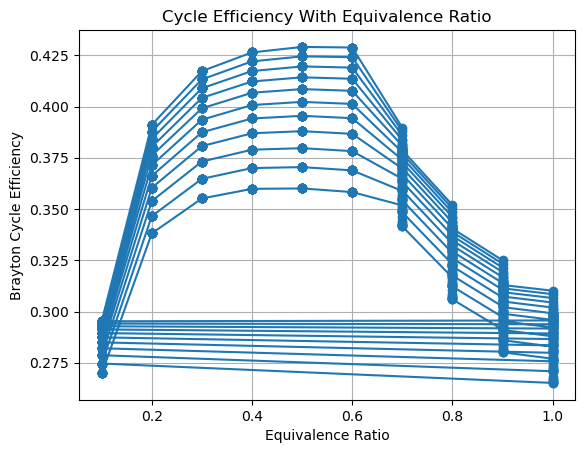

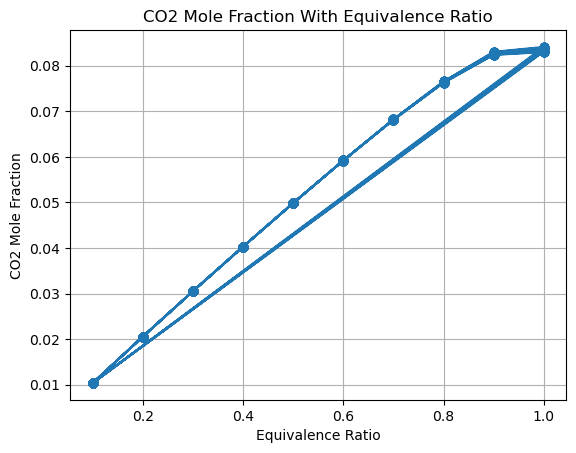

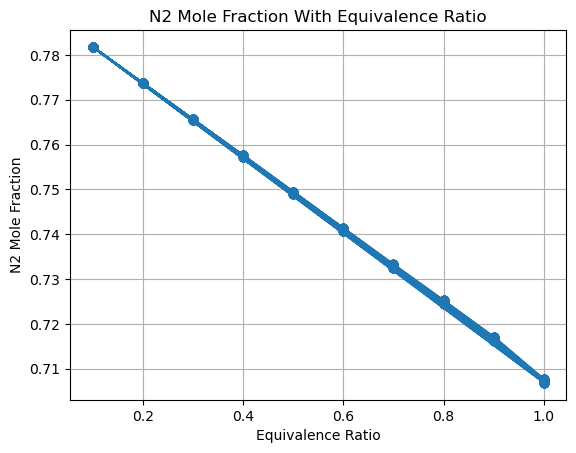

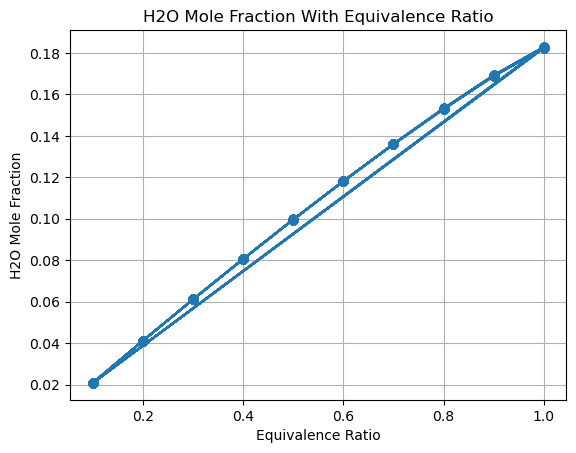

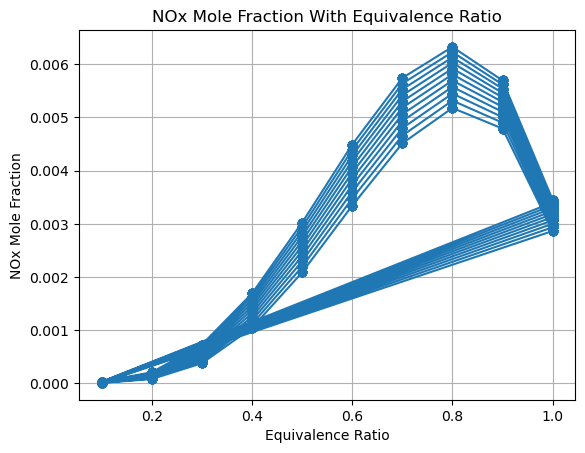

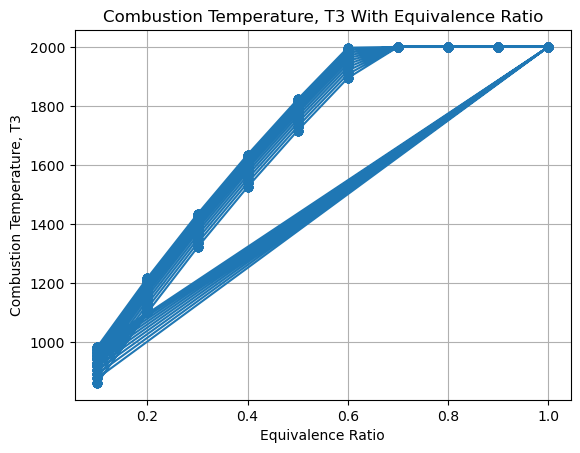

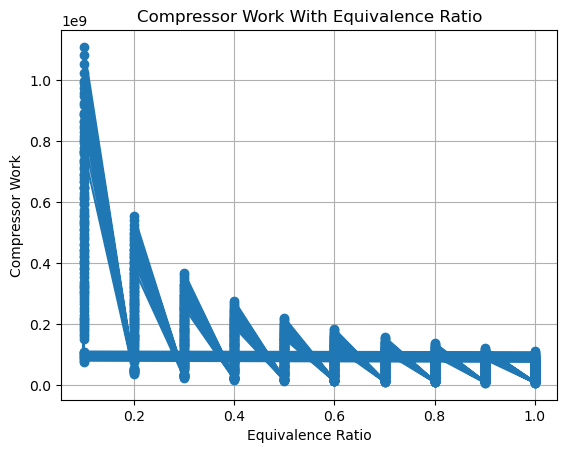

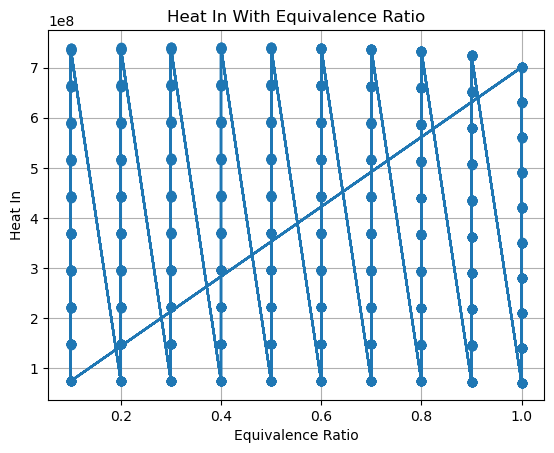

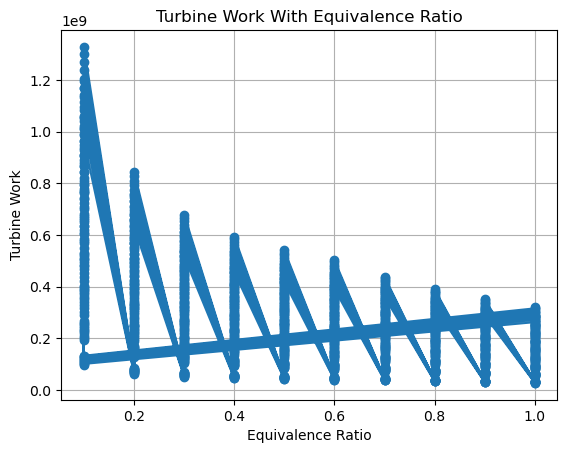

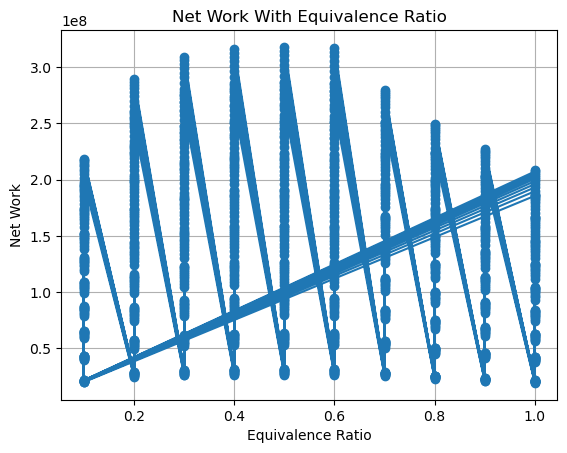

In [5]:
Loop_PR_Equi_CH4Frac = [Pressure_Ratio_vals, equi_phi_vals, CH4_Frac_vals, T3_vals, T3_Actual_vals, Compressor_Work_vals, Cooling_Air_Mass_vals, Heat_in_vals, Turbine_Work_vals, Net_Work_vals, Cycle_Eff_vals, CO2_mole_fraction_vals, NOx_mole_fraction_vals, H2O_mole_fraction_vals, CO2_mass_fraction_vals, NOx_mass_fraction_vals, H2O_mass_fraction_vals, N2_mole_fraction_vals, N2_mass_fraction_vals]
np.savetxt('All_Values-GRI.csv', Loop_PR_Equi_CH4Frac, delimiter=",", fmt='%s')

plt.figure(1)
plt.plot(equi_phi_vals, Cycle_Eff_vals, marker='o', linestyle='-')
plt.xlabel('Equivalence Ratio')
plt.ylabel('Brayton Cycle Efficiency')
plt.title('Cycle Efficiency With Equivalence Ratio')
plt.grid()
plt.show()

plt.figure(2)
plt.plot(equi_phi_vals, CO2_mole_fraction_vals, marker='o', linestyle='-')
plt.xlabel('Equivalence Ratio')
plt.ylabel('CO2 Mole Fraction')
plt.title('CO2 Mole Fraction With Equivalence Ratio')
plt.grid()
plt.show()

plt.figure(3)
plt.plot(equi_phi_vals, N2_mole_fraction_vals, marker='o', linestyle='-')
plt.xlabel('Equivalence Ratio')
plt.ylabel('N2 Mole Fraction')
plt.title('N2 Mole Fraction With Equivalence Ratio')
plt.grid()
plt.show()

plt.figure(4)
plt.plot(equi_phi_vals, H2O_mole_fraction_vals, marker='o', linestyle='-')
plt.xlabel('Equivalence Ratio')
plt.ylabel('H2O Mole Fraction')
plt.title('H2O Mole Fraction With Equivalence Ratio')
plt.grid()
plt.show()

plt.figure(5)
plt.plot(equi_phi_vals, NOx_mole_fraction_vals, marker='o', linestyle='-')
plt.xlabel('Equivalence Ratio')
plt.ylabel('NOx Mole Fraction')
plt.title('NOx Mole Fraction With Equivalence Ratio')
plt.grid()
plt.show()

plt.figure(6)
plt.plot(equi_phi_vals, T3_vals, marker='o', linestyle='-')
plt.xlabel('Equivalence Ratio')
plt.ylabel('Combustion Temperature, T3')
plt.title('Combustion Temperature, T3 With Equivalence Ratio')
plt.grid()
plt.show()

plt.figure(7)
plt.plot(equi_phi_vals, Compressor_Work_vals, marker='o', linestyle='-')
plt.xlabel('Equivalence Ratio')
plt.ylabel('Compressor Work')
plt.title('Compressor Work With Equivalence Ratio')
plt.grid()
plt.show()

plt.figure(8)
plt.plot(equi_phi_vals, Heat_in_vals, marker='o', linestyle='-')
plt.xlabel('Equivalence Ratio')
plt.ylabel('Heat In')
plt.title('Heat In With Equivalence Ratio')
plt.grid()
plt.show()

plt.figure(9)
plt.plot(equi_phi_vals, Turbine_Work_vals, marker='o', linestyle='-')
plt.xlabel('Equivalence Ratio')
plt.ylabel('Turbine Work')
plt.title('Turbine Work With Equivalence Ratio')
plt.grid()
plt.show()

plt.figure(10)
plt.plot(equi_phi_vals, Net_Work_vals, marker='o', linestyle='-')
plt.xlabel('Equivalence Ratio')
plt.ylabel('Net Work')
plt.title('Net Work With Equivalence Ratio')
plt.grid()
plt.show()

# plt.figure(7)
# plt.plot(equi_phi_vals, SOX_mole_fraction_vals, marker='o', linestyle='-')
# plt.xlabel('Equivalence Ratio')
# plt.ylabel('SOx Mole Fraction')
# plt.title('SOx Mole Fraction With Equivalence Ratio')
# plt.grid()
# plt.show()